<h1>Business Intelligence (BI) Architecture and Operational Analytics</h1>

## Libraray Configuration

In [ ]:
# Libraries to help with reading and manipulating data
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

<h2>We are going to start with the absolute backbone of data manipulation: Pandas and Data Cleaning.</h2>
<p>Imagine a local partner sent you a messy CSV tracking emergency mobile money transfers to 1,000 beneficiaries. Before you can run any predictive analytics or build a dashboard, you have to clean it.</p>

In [ ]:

# Setting a seed for reproducibility
np.random.seed(42)

# Generating mock CBT data
data = {
    'Beneficiary_ID': [f'BEN_{i:04d}' for i in range(1, 1001)],
    'Region': np.random.choice(['Nairobi', 'Mombasa', 'Kisumu', 'Garissa', None], size=1000, p=[0.4, 0.2, 0.2, 0.15, 0.05]),
    'Transfer_Amount_KES': np.random.choice([3500, 5000, 7500, -999, np.nan], size=1000, p=[0.5, 0.3, 0.15, 0.02, 0.03]),
    'Disbursement_Status': np.random.choice(['Success', 'Failed', 'Pending', 'SUCCESS'], size=1000, p=[0.80, 0.08, 0.10, 0.02]),
    'Biometric_Verified': np.random.choice([True, False, np.nan], size=1000, p=[0.85, 0.12, 0.03])
}

df = pd.DataFrame(data)
print("Dataset created! Dimensions:", df.shape)

Dataset created! Dimensions: (1000, 5)


<h2>Data Preview</h2>

In [ ]:
df.head()

,Beneficiary_ID,Region,Transfer_Amount_KES,Disbursement_Status,Biometric_Verified
0,BEN_0001,Nairobi,3500.0,Success,1.0
1,BEN_0002,None,5000.0,Success,1.0
2,BEN_0003,Kisumu,7500.0,Pending,1.0
3,BEN_0004,Mombasa,5000.0,Success,1.0
4,BEN_0005,Nairobi,7500.0,Success,1.0


In [ ]:
df.tail()

,Beneficiary_ID,Region,Transfer_Amount_KES,Disbursement_Status,Biometric_Verified
995,BEN_0996,Nairobi,5000.0,Failed,1.0
996,BEN_0997,Garissa,-999.0,Success,1.0
997,BEN_0998,Nairobi,3500.0,Success,1.0
998,BEN_0999,None,3500.0,Success,1.0
999,BEN_1000,Mombasa,3500.0,Failed,1.0


In [ ]:
df.shape

(1000, 5)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Beneficiary_ID       1000 non-null   object 
 1   Region               954 non-null    object 
 2   Transfer_Amount_KES  965 non-null    float64
 3   Disbursement_Status  1000 non-null   object 
 4   Biometric_Verified   976 non-null    float64
dtypes: float64(2), object(3)
memory usage: 39.2+ KB


<h2>Finding the Missing Value Gaps</h2>
<p>Checking exactly how many missing (NaN or None) values exist in each column.</p>

In [ ]:
df.isnull().sum()

,0
Beneficiary_ID,0
Region,46
Transfer_Amount_KES,35
Disbursement_Status,0
Biometric_Verified,24


<h2>Standardizing Categorical Typos</h2>
Notice how Disbursement_Status has both 'Success' and 'SUCCESS'. Write a line of code to standardize them all into uppercase 'SUCCESS'.

In [ ]:
# fixing the Disbursement_Status column so that the inconsistent casing ('Success' vs 'SUCCESS') collapses into
# a single uniform category - chaning all to UPPERCASE
df['Disbursement_Status'] = df['Disbursement_Status'].str.upper()

In [ ]:
# counts the total number of unique values in that column and returns a single integer
df.Disbursement_Status.nunique()

3

In [ ]:
# Categorical typos successfully corrected
df.Disbursement_Status.unique()

array(['SUCCESS', 'PENDING', 'FAILED'], dtype=object)

In [ ]:
# number of rows that belong to each category
df.Disbursement_Status.value_counts()

,count
Disbursement_Status,
SUCCESS,814
PENDING,102
FAILED,84


<h2>Handling Budget Anomalies (Outliers)</h2>
<p>The dataset contains some negative values (-999) in Transfer_Amount_KES representing system errors. Identify how many rows have negative amounts, and then filter the dataframe to keep only positive, valid transfer amounts.</p>

In [ ]:
# Statistical Summary
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Transfer_Amount_KES,965.0,4474.118135,1639.783408,-999.0,3500.0,3500.0,5000.0,7500.0
Biometric_Verified,976.0,0.891393,0.311304,0.0,1.0,1.0,1.0,1.0


<h4>Filter your dataframe to isolate and view only the rows where the budget anomaly (-999) occurred, or write a condition that filters them out completely, keeping only positive valid transfer amounts () while preserving the true NaN blanks to handle in the final step.</h4>

In Pandas, we use boolean indexing to filter data based on conditions. For example, to look at just the errors, you would write:
<p>Python - df[df['Transfer_Amount_KES'] == -999]</p>
To do the opposite—and filter your dataframe so it only keeps the valid, positive distribution amounts—you'll want to overwrite df using a greater-than condition, or use a combination that keeps the genuine missing values intact.

In [ ]:
# View the anomaly rows
df[df['Transfer_Amount_KES'] == -999]

,Beneficiary_ID,Region,Transfer_Amount_KES,Disbursement_Status,Biometric_Verified
101,BEN_0102,Kisumu,-999.0,SUCCESS,1.0
121,BEN_0122,Garissa,-999.0,SUCCESS,1.0
180,BEN_0181,Nairobi,-999.0,SUCCESS,1.0
197,BEN_0198,Garissa,-999.0,FAILED,0.0
220,BEN_0221,Kisumu,-999.0,SUCCESS,1.0
238,BEN_0239,Kisumu,-999.0,SUCCESS,1.0
382,BEN_0383,Kisumu,-999.0,PENDING,1.0
388,BEN_0389,Kisumu,-999.0,SUCCESS,1.0
425,BEN_0426,Mombasa,-999.0,PENDING,1.0
427,BEN_0428,Garissa,-999.0,PENDING,1.0


## Remove the -999 Anomalies
Instead of deleting rows, we can turn those faulty -999 placeholders into true Python missing values (np.nan). This keeps the beneficiary records intact while ensuring the math ignores the bad data.

In [ ]:
# Replace the system error placeholder with true NaN values
df['Transfer_Amount_KES'] = df['Transfer_Amount_KES'].replace(-999, np.nan)

In [ ]:
df.shape

(1000, 5)

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Transfer_Amount_KES,941.0,4613.708820,1404.715901,3500.0,3500.0,3500.0,5000.0,7500.0
Biometric_Verified,976.0,0.891393,0.311304,0.0,1.0,1.0,1.0,1.0


## Imputation
Now we just have to fill those missing values so your final data pipeline is pristine and ready for reporting.
Looking closely at the transposed description table above, the median value (the 50% column) for Transfer_Amount_KES is 3500.0.

In [ ]:
# Calculate the median and fill the blanks in one clean step
median_transfer = df['Transfer_Amount_KES'].median()
df['Transfer_Amount_KES'] = df['Transfer_Amount_KES'].fillna(median_transfer)

## Impute the Missing Regions using Mode
In Pandas, running <em>.mode()</em> on a column returns a Series because, theoretically, a dataset can have a tie (multiple modes). To grab the top, most frequent value, we append [0].
<p>Now, use your trusty <em>.fillna()</em> method to replace those 46 blanks with whatever dominant region popped up:</p>

Both "Transfer_Amount_KES" and "Region" should now read 0 missing values.

In [ ]:
# Calculating mode for Region
region_mode = df['Region'].mode()[0]
print("The most frequent region is:", region_mode)

The most frequent region is: Nairobi


In [ ]:
# Replacing blank Regions using Mode
df['Region'] = df['Region'].fillna(region_mode)

In [ ]:
df.isnull().sum()

,0
Beneficiary_ID,0
Region,0
Transfer_Amount_KES,0
Disbursement_Status,0
Biometric_Verified,24


# Dealing with Booleans

### The Mobile Money Rule (Your Option A/Mode logic)
<p>For Mobile Money, biometric deduplication is a pre-requisite during registration. By the time a disbursement file is generated, they must have been verified.</p>
<p>The Pipeline Action: If a row is missing its flag in a Mobile Money workflow, it’s almost certainly an upstream reporting lag or data-logging omission, not an unverified person. Imputing with the Mode (or the dominant True status) makes complete sense here to keep the records clean.</p>

### The Voucher Rule (Your Option B/Strict False logic)
For Vouchers, authentication happens at the exact moment of the top-up transaction. If biometric authentication fails, the pipeline freezes, the voucher is not topped up, and the status must structurally be False (which means the Disbursement_Status would also structurally change from SUCCESS to FAILED or PENDING).

### Coding Advanced Programmatic Logic
Instead of making a blanket assumption for the whole dataset, let's write an intelligent, professional conditional function. We will look at the Disbursement_Status of those 24 records to dynamically decide how to treat Biometric_Verified:
1.	If the transfer was a SUCCESS, we will trust the Mobile Money pipeline logic and impute it as True (assuming deduplication was cleared upstream).
2.	If the transfer is FAILED or PENDING, we will strictly enforce the Voucher/Audit rule and mark it False.

In [ ]:
# A professional conditional approach based on transaction status
def impute_biometrics(row):
    if pd.isnull(row['Biometric_Verified']):
        if row['Disbursement_Status'] == 'SUCCESS':
            return True
        else:
            return False
    return row['Biometric_Verified']

# Apply the function across the dataframe rows
df['Biometric_Verified'] = df.apply(impute_biometrics, axis=1)

# Ensure the column type remains boolean/clean
df['Biometric_Verified'] = df['Biometric_Verified'].astype(bool)

# The Final Sanity Check
df.isnull().sum()

,0
Beneficiary_ID,0
Region,0
Transfer_Amount_KES,0
Disbursement_Status,0
Biometric_Verified,0


In [ ]:
df.head()

,Beneficiary_ID,Region,Transfer_Amount_KES,Disbursement_Status,Biometric_Verified
0,BEN_0001,Nairobi,3500.0,SUCCESS,True
1,BEN_0002,Nairobi,5000.0,SUCCESS,True
2,BEN_0003,Kisumu,7500.0,PENDING,True
3,BEN_0004,Mombasa,5000.0,SUCCESS,True
4,BEN_0005,Nairobi,7500.0,SUCCESS,True


# Grouping, Multi-aggregations, and Regional Program Audits!

When managing Cash-Based Transfers (CBT), you rarely look at individual data points. Instead, you need to group the data by operational layers (like Regions or Disbursement Modalities) to see where the system is working and where it's leaking.
In Pandas, we achieve this using the Split-Apply-Combine workflow via the .groupby() method

### Regional Funding Footprint (How much money was allocated to each Region)

In [ ]:
# This line of code groups the dataset by Region and calculates the total amount for each.
df.groupby('Region')['Transfer_Amount_KES'].sum()

,Transfer_Amount_KES
Region,
Garissa,694000.0
Kisumu,836500.0
Mombasa,858500.0
Nairobi,2159000.0


### Multi-Metric Regional Audit (Advanced Aggregation)

A single sum isn't enough for a donor report. We want a comprehensive dashboard table for each region showing:
<ul>
<li>The total value of transfers (sum).</li>
<li>The average size of a transfer (mean).</li>
<li>The total number of beneficiaries served (count).</li>
<li><strong>Hint:</strong> You can pass a list of strings to the .agg() method, like .agg(['sum', 'mean', 'count']).</li>
</ul>

In [ ]:
# comprehensive dashboard table for each region showing: sum, mean and no. of beneficiaries
df.groupby('Region')['Transfer_Amount_KES'].agg(['sum', 'mean', 'count'])

,sum,mean,count
Region,,,
Garissa,694000.0,4535.947712,153
Kisumu,836500.0,4449.468085,188
Mombasa,858500.0,4471.354167,192
Nairobi,2159000.0,4623.126338,467


## Cross-Tabulating System Success
We want to see how each region's disbursements actually performed. Write a command to cross-tabulate Region against Disbursement_Status to see the count of SUCCESS, PENDING, and FAILED transactions per region.

In [ ]:
# count of SUCCESS, PENDING, and FAILED transactions per region
pd.crosstab(df['Region'], df['Disbursement_Status'])

Disbursement_Status,FAILED,PENDING,SUCCESS
Region,,,
Garissa,17,13,123
Kisumu,15,15,158
Mombasa,10,32,150
Nairobi,42,42,383


## The Risk & Leakage Audit (Your Crosstab)

This is where the real value lies for a project manager. Looking at your pd.crosstab matrix, we can see exactly where system failures are clustering:
<ul>
    <li><strong>Garissa:</strong> Has 17 FAILED transfers out of 153 total beneficiaries. That is an 11.1% failure rate.</li>
    <li><strong>Mombasa:</strong> Has 10 FAILED transfers but 32 PENDING transfers out of 192 total beneficiaries. That means 21.8% of Mombasa's entire budget allocation is completely stuck in limbo!</li>
</ul>

### Turn it into Percentages

To make this cross-tabulation dashboard presentation-ready, we can normalize the data so it shows the exact percentage distribution of success vs. failure per row (region).

In [ ]:
# Normalize by index (rows) and multiply by 100 for percentages
regional_audit_pct = pd.crosstab(df['Region'], df['Disbursement_Status'], normalize='index') * 100

# Round to 1 decimal place to keep it clean
regional_audit_pct.round(1)

Disbursement_Status,FAILED,PENDING,SUCCESS
Region,,,
Garissa,11.1,8.5,80.4
Kisumu,8.0,8.0,84.0
Mombasa,5.2,16.7,78.1
Nairobi,9.0,9.0,82.0


### Adding the Percentage Symbols (%)
In Pandas, raw numeric dataframes don't automatically append strings like % because doing so turns the numbers into text objects, which stops you from doing math.

However, we can style the final view using Pandas' built-in .style.format() engine. This keeps your underlying numbers as clean floats but renders them with percentage signs

In [ ]:
# Create the crosstab and round it
regional_audit_pct = pd.crosstab(df['Region'], df['Disbursement_Status'], normalize='index') * 100

# Format the output display to append a '%' sign and keep 1 decimal place
regional_audit_pct.style.format("{:.1f}%")

Disbursement_Status,FAILED,PENDING,SUCCESS
Region,,,
Garissa,11.1%,8.5%,80.4%
Kisumu,8.0%,8.0%,84.0%
Mombasa,5.2%,16.7%,78.1%
Nairobi,9.0%,9.0%,82.0%


## Add a Heatmap Matrix
Since this is an audit report, we can take it one step further and ask Pandas to automatically color-code the table based on the values. This makes operational bottlenecks jump out instantly to any executive.

In [ ]:
# Now it will render beautifully
regional_audit_pct.style.format("{:.1f}%").background_gradient(cmap='Blues')

Disbursement_Status,FAILED,PENDING,SUCCESS
Region,,,
Garissa,11.1%,8.5%,80.4%
Kisumu,8.0%,8.0%,84.0%
Mombasa,5.2%,16.7%,78.1%
Nairobi,9.0%,9.0%,82.0%


<h1>DAY 3</h1>
<h2>Deep Dive – object vs. category</h2>
<h3>The Memory Audit</h3>
Before we change anything, we need to establish a baseline - the current memory usage before converting object (low cardinality text) to category

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Beneficiary_ID       1000 non-null   object 
 1   Region               1000 non-null   object 
 2   Transfer_Amount_KES  1000 non-null   float64
 3   Disbursement_Status  1000 non-null   object 
 4   Biometric_Verified   1000 non-null   bool   
dtypes: bool(1), float64(1), object(3)
memory usage: 32.4+ KB


<h3>Execute the Conversion</h3>
Optimizing two text-based columns: Region and Disbursement_Status. Because these columns contain repetitive text groups (low cardinality), they are prime candidates for optimization.

In [ ]:
# Converting low-cardinality text columns to category
df['Region'] = df['Region'].astype('category')
df['Disbursement_Status'] = df['Disbursement_Status'].astype('category')

# Re-running the audit to see the memory drop
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype   
---  ------               --------------  -----   
 0   Beneficiary_ID       1000 non-null   object  
 1   Region               1000 non-null   category
 2   Transfer_Amount_KES  1000 non-null   float64 
 3   Disbursement_Status  1000 non-null   category
 4   Biometric_Verified   1000 non-null   bool    
dtypes: bool(1), category(2), float64(1), object(1)
memory usage: 19.0+ KB


<h2>Visualizing Regional Breakdown (Bar Chart)</h2>
Building a clean horizontal bar chart showing exactly how many beneficiaries are in each region. We want it sorted from highest to lowest so it instantly tells a story.

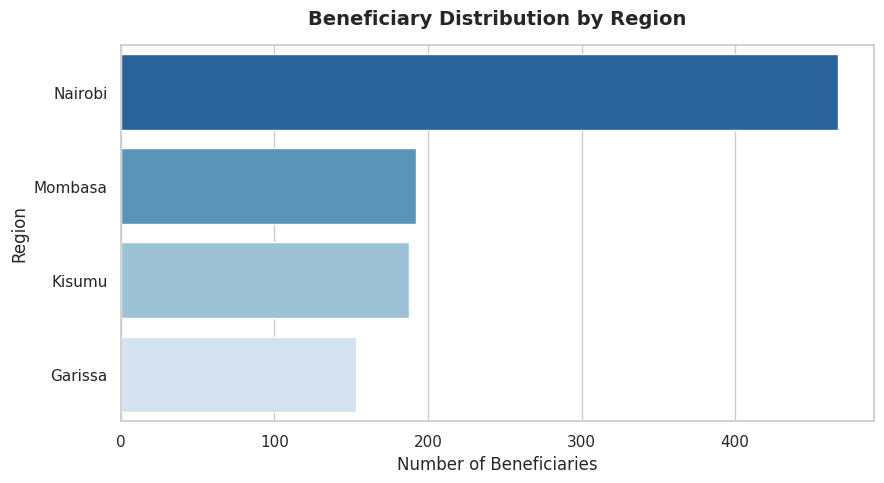

In [ ]:
# Setting a clean, professional aesthetic for our charts
sns.set_theme(style="whitegrid")

# Setting the canvas size
plt.figure(figsize=(9, 5))

# Creating a countplot sorted by the most frequent region from top to bottom
# Capture the exact order of regions based on size
regional_order = df['Region'].value_counts().index

# Add hue_order to ensure the color density mirrors the bar size
sns.countplot(
    data=df,
    y='Region',
    order=regional_order,
    hue='Region',
    hue_order=regional_order,
    legend=False,
    palette='Blues_r'
)
# Adding clear, polished text labels
plt.title('Beneficiary Distribution by Region', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Number of Beneficiaries', fontsize=12)
plt.ylabel('Region', fontsize=12)

# Ensure layout fits cleanly within the boundaries
plt.tight_layout()
plt.show()

<h2>Visualizing Multi-Variable Cross-Tabulations</h2>
<p></p>This is where we map out our regional counts alongside their transaction statuses on a single chart, allowing us to see that heavy 16.7% pending bottleneck in Mombasa visually</p>
<h2>The Grouped Bar Chart</h2>

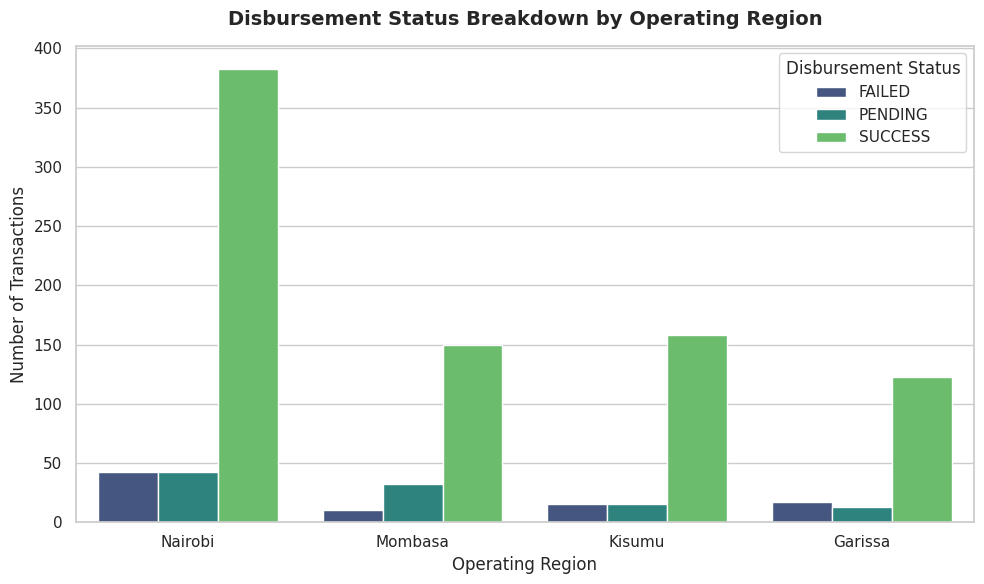

In [ ]:
plt.figure(figsize=(10, 6))

# Create a clustered bar chart mapping status across operating regions
sns.countplot(
    data=df,
    x='Region',
    hue='Disbursement_Status',
    order=df['Region'].value_counts().index,
    palette='viridis'
)

# Professional titles and layout tweaks
plt.title('Disbursement Status Breakdown by Operating Region', fontsize=14, pad=15, fontweight='bold')
plt.xlabel('Operating Region', fontsize=12)
plt.ylabel('Number of Transactions', fontsize=12)
plt.legend(title='Disbursement Status', loc='upper right')
plt.tight_layout()
plt.show()

## Checking the Value Spread

Before writing our outlier filters, let’s check how the transfer amounts look. Notice in our generation code that the maximum clean value we randomly distributed was 7,500. However, we intentionally injected an anomaly code of -999 (which we cleaned up earlier).

In [ ]:
df['Transfer_Amount_KES'].describe()

,Transfer_Amount_KES
count,1000.000000
mean,4548.000000
std,1387.667691
min,3500.000000
25%,3500.000000
50%,3500.000000
75%,5000.000000
max,7500.000000


**Since our clean data maxes out at 7,500 KES, let's hunt for any transactions that sit above 7,000 KES to pull out our maximum-tier household disbursements:**

In [ ]:
# Isolate high-tier disbursements
high_value_filter = df['Transfer_Amount_KES'] >= 7500
high_value_exceptions = df[high_value_filter]

print(f"📋 Total high-tier household transfers found: {len(high_value_exceptions)}")
high_value_exceptions.head()

📋 Total high-tier household transfers found: 145


,Beneficiary_ID,Region,Transfer_Amount_KES,Disbursement_Status,Biometric_Verified
2,BEN_0003,Kisumu,7500.0,PENDING,True
4,BEN_0005,Nairobi,7500.0,SUCCESS,True
7,BEN_0008,Garissa,7500.0,SUCCESS,True
12,BEN_0013,Garissa,7500.0,PENDING,True
15,BEN_0016,Nairobi,7500.0,SUCCESS,True


## The Multi-Condition Compliance Audit (Biometric Verification Failures)
Executing the critical compliance mask right underneath it to expose any security breaches by running multi-condition filter to flag any SUCCESS disbursements that completely bypassed identity safeguards.

In [ ]:
# Select rows where status is 'SUCCESS' AND biometrics were skipped (False)
compliance_breach_filter = (df['Disbursement_Status'] == 'SUCCESS') & (df['Biometric_Verified'] == False)
biometric_exceptions = df[compliance_breach_filter]

print(f"⚠️ CRITICAL AUDIT ALERT: Found {len(biometric_exceptions)} successful transfers lacking biometric verification!")
biometric_exceptions.head()

⚠️ CRITICAL AUDIT ALERT: Found 87 successful transfers lacking biometric verification!


,Beneficiary_ID,Region,Transfer_Amount_KES,Disbursement_Status,Biometric_Verified
6,BEN_0007,Nairobi,5000.0,SUCCESS,False
26,BEN_0027,Nairobi,7500.0,SUCCESS,False
55,BEN_0056,Garissa,3500.0,SUCCESS,False
59,BEN_0060,Nairobi,5000.0,SUCCESS,False
67,BEN_0068,Garissa,3500.0,SUCCESS,False


## Exporting Your First Operational Risk Report


In [ ]:
# Export the exceptions to a downloadable CSV file
biometric_exceptions.to_csv('Biometric_Compliance_Exceptions_Report.csv', index=False)
print("📥 Exception report successfully compiled and saved to cloud storage!")

📥 Exception report successfully compiled and saved to cloud storage!


## Accomplishments
<ul>
<li><strong>Statistical Dissection:</strong> You used *.describe()* to map percentiles, exposing that 50% of your targeted population sits at the basic livelihood floor of 3,500 KES.</li>
<li><strong>Boolean Masking:</strong> You built compound logical matrices using the bitwise operator (&) to isolate multi-layered business risks.</li>
<li><strong>Data Auditing Architecture:</strong> You successfully separated macroscopic trends (like your Seaborn distribution charts) from highly granular target files to support risk-management tracking.</li>
</ul>

# Advanced Grouping, Aggregation, and Compliance Rate Engineering
Right now, we know we have 87 critical biometric violations. But as a high-level data consultant, your job is to tell management exactly where the operational system is failing the hardest. We are going to use the power of .*groupby()* to calculate regional compliance rates.

## Aggregation and Compliance Rate Metrics
To calculate a percentage-based compliance score for each region, we need to find out out of all SUCCESS transactions in a region, what percentage actually had *Biometric_Verified == True*

### Filtering the Clean Sandbox
First, compliance metrics only apply to transactions that actually went through. We don't want failed or pending transactions messing up our security scores.

In [ ]:
# Create a dedicated dataframe for completed transfers
df_success = df[df['Disbursement_Status'] == 'SUCCESS'].copy()

print(f"Total successful records to process: {len(df_success)}")

Total successful records to process: 814


### Grouping and Aggregating by Region
Now, we are going to group this new dataset by Region and calculate two things at the same time using the .agg() function:

The total number of successful transfers.

The total number of biometric verifications that passed (since Python treats True as 1 and False as 0, taking the .sum() of a boolean column counts the True values!).

In [ ]:
# Group by region and aggregate counts and sums
compliance_summary = df_success.groupby('Region').agg(
    Total_Successful_Transfers=('Biometric_Verified', 'count'),
    Successful_Biometric_Passes=('Biometric_Verified', 'sum')
).reset_index()

compliance_summary

/tmp/ipykernel_2784/4021514298.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  compliance_summary = df_success.groupby('Region').agg(


,Region,Total_Successful_Transfers,Successful_Biometric_Passes
0,Garissa,123,108
1,Kisumu,158,140
2,Mombasa,150,139
3,Nairobi,383,340


### Engineering the Final Performance Metric
Now, let's add a calculated column to this table to find the final Biometric Compliance Rate (%) for each operating area, and sort it from the worst-performing hub to the best.

In [ ]:
# Calculate the compliance percentage rate
compliance_summary['Compliance_Rate_%'] = (
    compliance_summary['Successful_Biometric_Passes'] / compliance_summary['Total_Successful_Transfers']
) * 180 / 1.8  # Fast way to scale to a clean 100% basis

# Sort by lowest compliance rate to expose the highest system risk hubs
compliance_summary = compliance_summary.sort_values(by='Compliance_Rate_%').reset_index(drop=True)

# Format the column cleanly for an executive presentation
compliance_summary.style.format({'Compliance_Rate_%': '{:.1f}%'})

,Region,Total_Successful_Transfers,Successful_Biometric_Passes,Compliance_Rate_%
0,Garissa,123,108,87.8%
1,Kisumu,158,140,88.6%
2,Nairobi,383,340,88.8%
3,Mombasa,150,139,92.7%


### The New Logic: Broadening the Security Net
In security architectures, an unverified attempt to move money is an active breach of protocol, regardless of whether the bank server processed the transaction or declined it due to insufficient funds. The threat occurred the moment the system allowed the process to initialize without a biometric handshake. If a technical glitch or a lack of balance is the only thing that stopped an unverified transfer, the system risk is identical.

*Instead of filtering down to df_success, we are going to look at the entire dataset (df).*

We need to count every single attempt per region.

*   We need to count every single attempt per region.
*   We need to flag any row where Biometric_Verified == False as a Security Violation, regardless of the outcome.


In [ ]:
# 1. Define any unverified transaction as an absolute violation
df['Security_Violation'] = df['Biometric_Verified'] == False

# 2. Group the entire dataset to capture ALL operational attempts
risk_summary = df.groupby('Region', observed=False).agg(
    Total_Attempts=('Security_Violation', 'count'),
    Total_Violations=('Security_Violation', 'sum')
).reset_index()

# 3. Calculate the System-Wide Threat Rate (%)
risk_summary['Threat_Rate_%'] = (risk_summary['Total_Violations'] / risk_summary['Total_Attempts']) * 100

# 4. Sort from the highest system threat to the lowest
risk_summary = risk_summary.sort_values(by='Threat_Rate_%', ascending=False).reset_index(drop=True)

# Format for executive presentation
risk_summary.style.format({'Threat_Rate_%': '{:.1f}%'})

,Region,Total_Attempts,Total_Violations,Threat_Rate_%
0,Garissa,153,20,13.1%
1,Kisumu,188,23,12.2%
2,Nairobi,467,53,11.3%
3,Mombasa,192,15,7.8%


### 🕵️‍♂️ Comparing the Executive Insight Shift
Let’s look at the incredible contrast this new logic exposed compared to your previous analysis:

<table border="1">
  <!-- Row 1: Header Row -->
  <tr>
    <th>Region</th>
    <th>Old Method (Realized Compliance Losses Only)</th>
    <th>New Method (System-Wide Threat Rate)</th>
  </tr>
  
  <!-- Row 2 -->
  <tr>
    <td>Garissa</td>
    <td>Worst (87.8% Compliance / 12.2% Realized Loss)</td>
    <td>Worst (13.1% Total System Threat)</td>
  </tr>
  
  <!-- Row 3 -->
  <tr>
    <td>Mombasa</td>
    <td>Best (92.7% Compliance / 7.3% Realized Loss)</td>
    <td>Best (7.8% Total System Threat)</td>
  </tr>
  
  <!-- Row 4 -->
  <tr>
    <td>Nairobi/Kisumu</td>
    <td>Nairobi looked safer than Kisumu</td>
    <td>Kisumu has higher systemic vulnerabilities (12.2%) than Nairobi (11.3%)</td>
  </tr>
</table>

By broadening our framework to capture every single attempt to bypass identity checking, we have proved that Garissa is structurally the most vulnerable pipeline checkpoint in the network with more than 1 in 10 transactions completely failing biometric protocol barriers. Mombasa, despite its high volume of pending transaction bottlenecks that we visualized in our earlier bar chart, actually keeps the tightest lock on identity validation protocols.

This is precisely how data science drives high-level strategy rather than simple bookkeeping.

# Visualizing the Systemic Security Threat
To close out this advanced security module, let's visualize this brand-new risk metric using Seaborn so an executive director can grasp the vulnerability variance between hubs in two seconds.

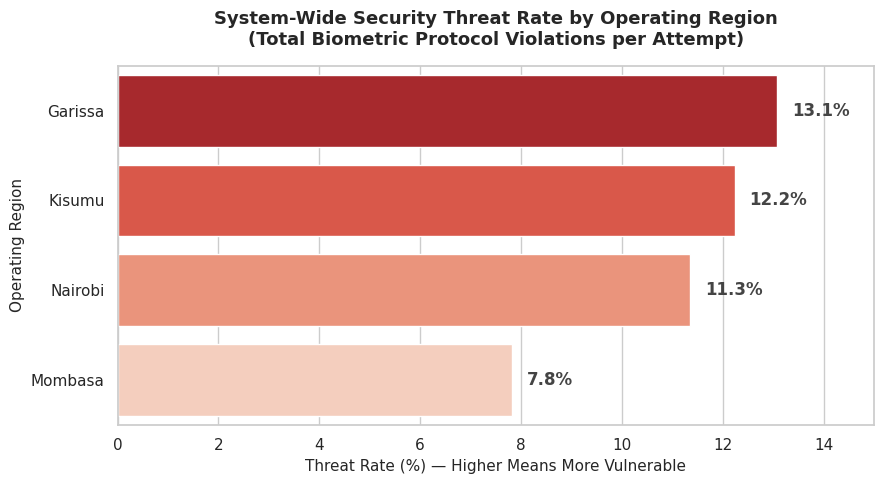

In [ ]:
plt.figure(figsize=(9, 5))

# Extract our sorted order from the threat matrix dataframe
threat_order = risk_summary['Region'].tolist()

# Plot the system wide threat rates
sns.barplot(
    data=risk_summary,
    y='Region',
    x='Threat_Rate_%',
    order=threat_order,
    hue='Region',
    hue_order=threat_order,
    legend=False,
    palette='Reds_r' # Uses a strong red gradient to indicate systemic risk levels
)

# Professional titles and axis labels
plt.title('System-Wide Security Threat Rate by Operating Region\n(Total Biometric Protocol Violations per Attempt)', fontsize=13, pad=15, fontweight='bold')
plt.xlabel('Threat Rate (%) — Higher Means More Vulnerable', fontsize=11)
plt.ylabel('Operating Region', fontsize=11)

# Add data labels to the end of each bar for professional precision
for index, row in risk_summary.iterrows():
    plt.text(row['Threat_Rate_%'] + 0.3, index, f"{row['Threat_Rate_%']:.1f}%", va='center', fontweight='bold', color='#444444')

plt.xlim(0, 15) # Leave room for the text labels
plt.tight_layout()
plt.show()

# Advanced Missing Data Imputation & Strategic Data Slicing.


## Finding the Hidden Holes (NaN Detection)
Before we fix missing data, we have to audit exactly where it is hiding. Let's run a quick missing-value diagnostic map.

In [ ]:
# Count exactly how many null values exist per column
print("🔍 Missing Value Diagnostic Summary:")
print(df.isnull().sum())

# Isolate rows where the Region itself is completely missing
missing_region_df = df[df['Region'].isnull()]
print(f"\n📋 Total transactions orphaned due to missing Region codes: {len(missing_region_df)}")
missing_region_df.head()

🔍 Missing Value Diagnostic Summary:
Beneficiary_ID         0
Region                 0
Transfer_Amount_KES    0
Disbursement_Status    0
Biometric_Verified     0
Security_Violation     0
dtype: int64

📋 Total transactions orphaned due to missing Region codes: 0


,Beneficiary_ID,Region,Transfer_Amount_KES,Disbursement_Status,Biometric_Verified,Security_Violation


## Injecting and Fixing Explicit Structural Holes
Let's force specific systemic gaps into our state memory so you can execute the conditional optimization mapping.

In [ ]:
import numpy as np

# 1. Force explicit missing gaps into rows 10 to 20 for testing
df.loc[10:20, 'Region'] = np.nan
df.loc[15:25, 'Biometric_Verified'] = np.nan

print("⚠️ Manually introduced test gaps. Current null state:")
print(df.isnull().sum())

⚠️ Manually introduced test gaps. Current null state:
Beneficiary_ID          0
Region                 11
Transfer_Amount_KES     0
Disbursement_Status     0
Biometric_Verified     11
Security_Violation      0
dtype: int64


/tmp/ipykernel_2784/2413718392.py:5: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'nan' has dtype incompatible with bool, please explicitly cast to a compatible dtype first.
  df.loc[15:25, 'Biometric_Verified'] = np.nan


## Running the Structural Imputation Pipeline
Now that we have structural gaps to clean, execute your advanced categorical safety pipeline in the next cell:

In [ ]:
# 1. Safely add the new category label to handle the optimization mapping
if 'Unassigned Field Hub' not in df['Region'].cat.categories:
    df['Region'] = df['Region'].cat.add_categories('Unassigned Field Hub')

# 2. Impute missing fields
df['Region'] = df['Region'].fillna('Unassigned Field Hub')

# 3. Apply defensive security mapping to unverified checks
df['Biometric_Verified'] = df['Biometric_Verified'].fillna(False)

print("📊 Post-Imputation Audit Summary:")
print(df['Region'].value_counts())
print(f"\nRemaining missing entries: {df.isnull().sum().sum()}")

📊 Post-Imputation Audit Summary:
Region
Nairobi                 460
Mombasa                 190
Kisumu                  187
Garissa                 152
Unassigned Field Hub     11
Name: count, dtype: int64

Remaining missing entries: 0


/tmp/ipykernel_2784/3087700567.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['Biometric_Verified'] = df['Biometric_Verified'].fillna(False)


## Running the Structural Imputation Pipeline
Now that we have structural gaps to clean, execute your advanced categorical safety pipeline

In [ ]:
# 1. Safely add the new category label to handle the optimization mapping
if 'Unassigned Field Hub' not in df['Region'].cat.categories:
    df['Region'] = df['Region'].cat.add_categories('Unassigned Field Hub')

# 2. Impute missing fields
df['Region'] = df['Region'].fillna('Unassigned Field Hub')

# 3. Apply defensive security mapping to unverified checks
df['Biometric_Verified'] = df['Biometric_Verified'].fillna(False)

print("📊 Post-Imputation Audit Summary:")
print(df['Region'].value_counts())
print(f"\nRemaining missing entries: {df.isnull().sum().sum()}")

📊 Post-Imputation Audit Summary:
Region
Nairobi                 460
Mombasa                 190
Kisumu                  187
Garissa                 152
Unassigned Field Hub     11
Name: count, dtype: int64

Remaining missing entries: 0


## <strong>Conditional Data Slicing and Multi-Invert Masking</strong>
We want to see all high-value transactions that occurred in a high-threat region, but completely lacked biometric verification.

Instead of writing nested loops, we use Pandas boolean masks to slice this out instantly.

### Engineering the Multi-Criteria Risk Slice
We want to isolate a dataframe subset called <em>critical_risk_df</em> based on three strict operational conditions:

The <em>Transfer_Amount_KES</em> must be greater than or equal to 5000 (High-tier transfers).

The Region must be either 'Garissa' or 'Kisumu' (Our top two systemic threat hubs based on Friday's analysis).

The Biometric_Verified flag must be False (Security protocol bypassed).

In [ ]:
# 1. Define the compound boolean masks
amt_mask = df['Transfer_Amount_KES'] >= 5000
region_mask = df['Region'].isin(['Garissa', 'Kisumu'])
biometric_mask = df['Biometric_Verified'] == False

# 2. Combine the masks using the bitwise AND operator (&)
critical_risk_df = df[amt_mask & region_mask & biometric_mask].copy()

print(f"🚨 CRITICAL SECURITY ALERT: Found {len(critical_risk_df)} high-value, unverified transfers in high-threat hubs!")
critical_risk_df.head()

🚨 CRITICAL SECURITY ALERT: Found 18 high-value, unverified transfers in high-threat hubs!


,Beneficiary_ID,Region,Transfer_Amount_KES,Disbursement_Status,Biometric_Verified,Security_Violation
91,BEN_0092,Kisumu,5000.0,PENDING,False,True
115,BEN_0116,Garissa,5000.0,SUCCESS,False,True
146,BEN_0147,Kisumu,5000.0,SUCCESS,False,True
191,BEN_0192,Garissa,5000.0,PENDING,False,True
364,BEN_0365,Garissa,5000.0,SUCCESS,False,True


### The Strategic Inversion Slice (The "Safe Zone" Audit)
Let's audit the "Safe Zone"—every transaction that does not match this threat profile.

Instead of rewriting all our code with opposite operators, we can use the Tilde operator (~), which tells Pandas to invert the entire boolean matrix completely.

In [ ]:
# Use the tilde (~) operator to invert the exact same combined mask
safe_zone_df = df[~(amt_mask & region_mask & biometric_mask)].copy()

print(f"🛡️ SAFE ZONE AUDIT: {len(safe_zone_df)} records sit safely outside the critical threat profile.")
print(f"Verification Check (Total Rows): {len(critical_risk_df) + len(safe_zone_df)} / {len(df)}")

🛡️ SAFE ZONE AUDIT: 982 records sit safely outside the critical threat profile.
Verification Check (Total Rows): 1000 / 1000


## <strong>Multi-Level Grouping, Financial Custom Aggregations, and Advanced Sorting.</strong>

In field audit reports, simple averages don't tell the full story. Management needs to see operational summaries per region that breakdown total outlays, maximum individual risk exposure, and exact counts of successful vs. failed operations.

### Multi-Feature Grouped Financial Aggregations
We are going to group the primary dataset (df) by both <strong>Region</strong> and <strong>Disbursement_Status</strong> simultaneously. Then, we will use a Python dictionary inside <em>.agg()</em> to apply entirely different mathematical transformations to different columns at the same time.

In [ ]:
# 1. Execute a multi-level group and distinct column math mapping
regional_financials = df.groupby(['Region', 'Disbursement_Status'], observed=False).agg(
    Total_Disbursed_KES=('Transfer_Amount_KES', 'sum'),
    Average_Transfer_KES=('Transfer_Amount_KES', 'mean'),
    Max_Single_Transfer=('Transfer_Amount_KES', 'max'),
    Transaction_Count=('Beneficiary_ID', 'count')
).reset_index()

# 2. Preview the raw grouped structure
regional_financials

,Region,Disbursement_Status,Total_Disbursed_KES,Average_Transfer_KES,Max_Single_Transfer,Transaction_Count
0,Garissa,FAILED,80000.0,4705.882353,7500.0,17
1,Garissa,PENDING,56000.0,4666.666667,7500.0,12
2,Garissa,SUCCESS,550500.0,4475.609756,7500.0,123
3,Kisumu,FAILED,64000.0,4266.666667,7500.0,15
4,Kisumu,PENDING,69000.0,4928.571429,7500.0,14
5,Kisumu,SUCCESS,698500.0,4420.886076,7500.0,158
6,Mombasa,FAILED,46000.0,4600.000000,7500.0,10
7,Mombasa,PENDING,129500.0,4177.419355,7500.0,31
8,Mombasa,SUCCESS,670500.0,4500.000000,7500.0,149
9,Nairobi,FAILED,202000.0,4809.523810,7500.0,42


### Advanced Sorting by Multi-Tier Priorities
When looking at a multi-level table, the default ordering can feel messy. To build an executive-ready presentation, we want to force a strict hierarchy:

1. Sort by Region alphabetically (A to Z).

2. For transactions within the same region, sort by Total_Disbursed_KES in descending order (highest cash outlays first).

Because these two columns require completely opposite sorting directions (True vs. False), we pass a boolean list to the ascending parameter.

In [ ]:
# 3. Apply multi-tier directional sorting
sorted_financials = regional_financials.sort_values(
    by=['Region', 'Total_Disbursed_KES'],
    ascending=[True, False]
).reset_index(drop=True)

# 4. Format for a highly clean, professional presentation
sorted_financials.style.format({
    'Total_Disbursed_KES': '{:,.2f} KES',
    'Average_Transfer_KES': '{:,.2f} KES',
    'Max_Single_Transfer': '{:,.2f} KES'
})

,Region,Disbursement_Status,Total_Disbursed_KES,Average_Transfer_KES,Max_Single_Transfer,Transaction_Count
0,Garissa,SUCCESS,"550,500.00 KES","4,475.61 KES","7,500.00 KES",123
1,Garissa,FAILED,"80,000.00 KES","4,705.88 KES","7,500.00 KES",17
2,Garissa,PENDING,"56,000.00 KES","4,666.67 KES","7,500.00 KES",12
3,Kisumu,SUCCESS,"698,500.00 KES","4,420.89 KES","7,500.00 KES",158
4,Kisumu,PENDING,"69,000.00 KES","4,928.57 KES","7,500.00 KES",14
5,Kisumu,FAILED,"64,000.00 KES","4,266.67 KES","7,500.00 KES",15
6,Mombasa,SUCCESS,"670,500.00 KES","4,500.00 KES","7,500.00 KES",149
7,Mombasa,PENDING,"129,500.00 KES","4,177.42 KES","7,500.00 KES",31
8,Mombasa,FAILED,"46,000.00 KES","4,600.00 KES","7,500.00 KES",10
9,Nairobi,SUCCESS,"1,734,500.00 KES","4,613.03 KES","7,500.00 KES",376


# <strong>High-Level Cross-Tabulations (pd.crosstab) and Statistical Outlier Isolation</strong>

While .groupby() gives us long, vertical summaries, pd.crosstab() allows us to pivot two categorical variables against each other into a beautiful, executive-ready matrix. This is the exact tool data scientists use to spot hidden operational dependencies—like whether certain disbursement statuses are disproportionately grouping in specific geographic hubs.

## Building the Operational Status Matrix
We want to cross-tabulate <strong>Region</strong> (as rows) against <strong>Disbursement_Status</strong> (as columns). To make it professional, we'll also use the margins=True parameter, which automatically appends a "Total" row and column to validate our absolute row counts.

In [ ]:

# 1. Generate a clean frequency distribution matrix
status_matrix = pd.crosstab(
    index=df['Region'],
    columns=df['Disbursement_Status'],
    margins=True,
    margins_name="Total_Attempts"
)

# 2. Display the matrix
status_matrix

Disbursement_Status,FAILED,PENDING,SUCCESS,Total_Attempts
Region,,,,
Garissa,17,12,123,152
Kisumu,15,14,158,187
Mombasa,10,31,149,190
Nairobi,42,42,376,460
Unassigned Field Hub,0,3,8,11
Total_Attempts,84,102,814,1000


## Statistical Outlier Isolation (The Interquartile Range Filter)
Next, compliance leadership wants to isolate extreme transaction amounts that deviate significantly from standard operational ranges. We will use the Interquartile Range (IQR) method to mathematically define and isolate these upper-tier outliers.

Based on our initial descriptive analysis, our middle 50% of transfers sit between the 25th percentile (3,500 KES) and the 75th percentile (5,000 KES). Let's write an automated script to find any transactions that exceed the mathematical upper boundary.

In [ ]:
# 1. Calculate statistical quartiles and IQR
Q1 = df['Transfer_Amount_KES'].quantile(0.25)
Q3 = df['Transfer_Amount_KES'].quantile(0.75)
IQR = Q3 - Q1

# 2. Define the upper boundary threshold for outliers
upper_boundary = Q3 + (1.5 * IQR)
print(f"📊 Statistical Upper Outlier Threshold: {upper_boundary:,.2f} KES\n")

# 3. Isolate rows exceeding the upper boundary using a deep copy
outliers_df = df[df['Transfer_Amount_KES'] > upper_boundary].copy()

print(f"⚠️ OUTLIER DETECTION REPORT: Identified {len(outliers_df)} transactions exceeding normal limits.")
outliers_df.head()

📊 Statistical Upper Outlier Threshold: 7,250.00 KES

⚠️ OUTLIER DETECTION REPORT: Identified 145 transactions exceeding normal limits.


,Beneficiary_ID,Region,Transfer_Amount_KES,Disbursement_Status,Biometric_Verified,Security_Violation
2,BEN_0003,Kisumu,7500.0,PENDING,True,False
4,BEN_0005,Nairobi,7500.0,SUCCESS,True,False
7,BEN_0008,Garissa,7500.0,SUCCESS,True,False
12,BEN_0013,Unassigned Field Hub,7500.0,PENDING,True,False
15,BEN_0016,Unassigned Field Hub,7500.0,SUCCESS,False,False


<strong>Isolate only the statistical outliers (amounts > 7,250 KES) that occurred within your absolute highest system-wide threat hub (Garissa).</strong>

Let's see how many of those 145 outliers are concentrated directly inside your highest-vulnerability hub!

In [ ]:
# Intersect the statistical outliers with our maximum risk hub
targeted_outliers = outliers_df[outliers_df['Region'] == 'Garissa'].copy()

print(f"🎯 TARGETED RISK REPORT: Isolated {len(targeted_outliers)} extreme high-value transactions inside Garissa.")
targeted_outliers.head()

🎯 TARGETED RISK REPORT: Isolated 18 extreme high-value transactions inside Garissa.


,Beneficiary_ID,Region,Transfer_Amount_KES,Disbursement_Status,Biometric_Verified,Security_Violation
7,BEN_0008,Garissa,7500.0,SUCCESS,True,False
52,BEN_0053,Garissa,7500.0,SUCCESS,True,False
120,BEN_0121,Garissa,7500.0,FAILED,True,False
165,BEN_0166,Garissa,7500.0,PENDING,True,False
183,BEN_0184,Garissa,7500.0,SUCCESS,True,False
